In [57]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict,Literal,Annotated,operator
from pydantic import BaseModel,Field
from langchain_core.messages import SystemMessage,HumanMessage

In [58]:
generator_llm = ChatOllama(model='llama3.2:3b',temperature=0)    # take good llm's according to task i am using only ollama for free for learning 
evaluator_llm =ChatOllama(model='qwen2.5:3b',temperature=0)
optimizor_llm = ChatOllama(model='llama3.2:3b',temperature=0)

In [60]:
class tweetState(TypedDict):
    topic : str 
    tweet : str 
    evaluation : Literal['approved','needs_improvement']
    feedback : str 
    iteration: int
    max_iteration : int 
    tweet_history : Annotated[list[str],operator.add]
    feedback_history : Annotated[list[str],operator.add]

In [61]:
def generate_tweet(state:tweetState) -> tweetState:
    messages = [
        SystemMessage(content="you are a funny/clever twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
        """)
    ]
    
    # if (state['feedback']) : 
    #     prompt += f"Also this is the previous tweet {state['tweet']} and the feedback for this post which you need to keep in mind is {state['feedback']}"
    tweet = generator_llm.invoke(messages).content
    state['tweet'] = tweet
    state['tweet_history'] = [tweet]
    return state

In [62]:
class TweetEvaluation(BaseModel):
    evaluation: Literal[" approved", "needs improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="Constructive feedback for the tweet.")

structured_evaluation_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [63]:
def evaluate_tweet(state:tweetState) -> tweetState : 
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based originality, virality, and tweet format."),
        HumanMessage(content=f"""
        Evaluate the following tweet:
        on humor,
            Tweet: "{state['tweet']}"
            Use the criteria below to evaluate the tweet:
            1. Originality - Is this fresh, or have you seen it a hundred times before?
            2. Humor - Did it genuinely make you smile, laugh, or chuckle?
            3. Punchiness - Is it short, sharp, and scroll-stopping?
            4. Virality Potential - Would people retweet or share it?
            5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?
        Auto-reject if:
            - It's written in question-answer format (e.g•, "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g•, "Masterpieces of the auntie-uncle universe" or vague summaries)
        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs
        improvement"
        - feedback: One paragraph explaining the strengths and weaknesses
        """)
    ]
    response = structured_evaluation_llm.invoke(messages)
    state['evaluation'] = response.evaluation
    state['feedback'] = response.feedback
    state['feedback_history'] = [state['feedback']]
    return state
    

In [64]:
def optimize_tweet(state:tweetState) -> tweetState : 
    messages = [
    SystemMessage (content= "You punch up tweets for virality and humor based on given feedback. "), 
    HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback' ]}"
        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}.
        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    state['tweet'] = optimizor_llm.invoke(messages).content
    state['tweet_history'] = [state['tweet']]
    state['iteration'] = state['iteration']+1
    return state; 

In [65]:
def route_evaluation(state: tweetState) :
    if (state['evaluation']=='approved' or state['iteration'] > state['max_iteration']) : 
        return 'approved'
    else: 
        return 'optimize'

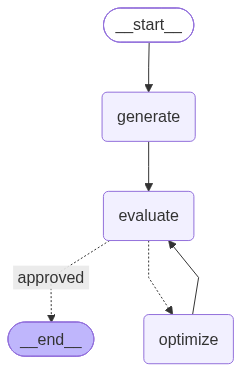

In [66]:
graph  = StateGraph(tweetState) 
graph.add_node("generate",generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved':END,'optimize':'optimize'})
graph.add_edge('optimize','evaluate')

workflow = graph.compile()

workflow

In [67]:
final_state = workflow.invoke({'topic':'indian railways ','iteration':1,'max_iteration':5})
final_state

{'topic': 'indian railways ',
 'tweet': 'Here\'s a rewritten tweet that\'s short, punchy, and under 280 characters:\n\n"Indian Railways: 12-hour delays = 1 hour of chai, 1 hour of nostalgia. Bonus points if you spot a cow on the platform! Who needs punctuality when you have nostalgia? #IndianRailways #DelaysAreMyLoveLanguage"\n\nHowever, to make it even more viral-worthy, I\'d suggest a slight tweak:\n\n"12-hour delays = 1 hour of chai, 1 hour of nostalgia. Bonus points if you spot a cow on the platform! Who needs punctuality when you have nostalgia? #IndianRailways #DelaysAreMyLoveLanguage"\n\nThis revised tweet is more concise and gets straight to the point, while still maintaining the playful tone and humor.',
 'evaluation': 'needs improvement',
 'feedback': 'The tweet is well-formed and concise, adhering to the 280 character limit. However, it lacks originality as it closely mirrors a common meme about Indian Railways. The humor is present and the tweet is punchy, but the content i

In [70]:
for tweet in final_state['tweet_history']:
    print(tweet,end='\n \n')

"Indian Railways: where a 12-hour delay is just a minor detour to the land of chai and nostalgia. Bonus points if you get to enjoy a free game of 'spot the cow' on the platform" #IndianRailways #DelaysAreMyLoveLanguage
 
"Indian Railways: where a 12-hour delay is just a minor detour to the land of chai and nostalgia. Bonus points if you get to enjoy a free game of 'spot the cow' on the platform" #IndianRailways #DelaysAreMyLoveLanguage
 
Here's a rewritten tweet that addresses the feedback:

"Indian Railways: where 12-hour delays are just a minor detour to chai & nostalgia. Bonus points if you get to enjoy a free game of 'spot the cow' on the platform"

I made the following changes:

* Removed the setup phrase and went straight to the punchline
* Kept the core idea of referencing Indian Railways' delays and the nostalgic aspect of Indian culture
* Removed the phrase "Bonus points" and replaced it with a more concise and punchy phrase "Bonus points"
* Kept the hashtag #IndianRailways an